In [1]:
import numpy as np
from datasets_ws import path_to_pil_img
import matplotlib.pyplot as plt
from os.path import join
import torchvision
from ipywidgets import interact, widgets, interactive, Layout
import ipywidgets
from glob import glob
import os
import cv2
import PIL.Image
import time

In [2]:
logfolder="../SUE_ensamble/preds/"
method_names=["original","finetuned"]
methods=["boq","salad","crica"]
predictions_dict= {"boq":[], "salad":[],"crica":[]}
dataset_names= ["amstertime","eynsham","nordland","sped"] #"msls"#"tokyo247"
datasets_folder="../datasets_vg/datasets/"
all_predictions=[]
corrects=[]
for key in predictions_dict.keys():
    method_pred={}
    correct_per_dataset={}
    
    for dataset_name in dataset_names:
        preds=[]
#         if dataset_name is "amstertime" and key == "salad":
#             logfolder="../VPR-methods-evaluation/logs/"
#         else:
#             logfolder="preds/"
        correct_per_dataset[dataset_name]=np.load(join(logfolder,f"correct_per_query_{dataset_name}.npy"), allow_pickle=True)
        preds.append(np.load(join(logfolder,f"predictions:{key}_original_on_{dataset_name}.npy")) if os.path.exists(join(logfolder,f"predictions:{key}_original_on_{dataset_name}.npy")) else None)
        preds.append(np.load(join(logfolder,f"predictions:{key}_finetuned_on_{dataset_name}.npy")) if os.path.exists(join(logfolder,f"predictions:{key}_finetuned_on_{dataset_name}.npy")) else None)
        method_pred[dataset_name]=preds
    all_predictions.append(method_pred)
    
    corrects.append(correct_per_dataset)
    
predictions_dict=dict(zip(methods,all_predictions))
correct_per_query_dict=dict(zip(methods,corrects))
#     predictions_dict[key]= [np.load(join(logfolder,f"predictions:{key}_{method}_on_{dataset_name}.npy")) if os.path.exists(join(logfolder,f"predictions:{key}_{method}_on_{dataset_name}.npy")) else None for method in method_names for dataset_name in dataset_names]
# all_predictions=[np.load(join(logfolder,f"predictions:{method}_on_{dataset_name}.npy")) for method in method_names]
# corrects_per_query=np.load(join(logfolder,f"correct_per_query_{dataset_name}.npy"), allow_pickle=True)

In [3]:
recall_values=[1]#, 5, 10, 20]
all_recalls=[]
corrects_dict= {"boq":{}, "salad":{},"crica":{}}
wrong_indices_dict={"boq":{}, "salad":{},"crica":{}}
correct_original={}
correct_finetuned={}
fine_tuned_all_wrong_dict={}
original_all_wrong_dict={}
fine_tuned_all_dict={}
original_all_dict={}
original_wrong_finetunednot_dict={}
fine_tuned_wrong_originalnot_dict={}

# method='crica'
# dataset_name="nordland"
for dataset_name in dataset_names:
    original=[]
    fine_tuned=[]
    
    for method in methods:
        all_predictions=predictions_dict[method][dataset_name]
        corrects_per_query=correct_per_query_dict[method][dataset_name]
        corrects_methods=[np.zeros(len(method),dtype=bool) for method in all_predictions]
        for method_id,method_preds in enumerate(all_predictions):
            recalls = np.zeros(len(recall_values))
            for query_index, preds in enumerate(method_preds):
                for i, n in enumerate(recall_values):
                    if np.any(np.in1d(preds[:n], corrects_per_query[query_index])):
                        recalls[i:] += 1
                        corrects_methods[method_id][query_index]=True
                        break
                all_recalls.append(recalls)

        corrects_methods=np.array(corrects_methods)
        
        corrects_dict[method][dataset_name]=corrects_methods
        
        wrongs=np.array([corrects_methods[0,i]!=corrects_methods[1,i] and corrects_methods[0,i]==False for i in range(len(corrects_methods[0]))])
        worse=np.array([corrects_methods[0,i]!=corrects_methods[1,i] and corrects_methods[0,i]==True for i in range(len(corrects_methods[0]))])
        compleet_fout=np.array([corrects_methods[0,i]==corrects_methods[1,i] and corrects_methods[0,i]==True for i in range(len(corrects_methods[0]))])
        wrong_indices=np.argwhere(wrongs).squeeze()
        wrong_indices_finetuned=np.argwhere(worse).squeeze()
        print(method,dataset_name)
        print(f"{wrongs.sum()} images were wrong for original but not finetuned  of {len(corrects_methods[0])} total queries orig wrong: {len(corrects_methods[0])-corrects_methods[0].sum()} wrong")
        print(f"{worse.sum()} images were wrong for finetuned but not original  of {len(corrects_methods[0])} total queriesfine wrong: {len(corrects_methods[1])-corrects_methods[1].sum()} wrong")
        print(f"original had ad recall @{recall_values[-1]} of {corrects_methods[0].sum()/len(corrects_methods[0])*100:.1f}, fine tuned had {corrects_methods[1].sum()/len(corrects_methods[1])*100:.1f}")
        print(corrects_methods[0].sum(),corrects_methods[1].sum())
        print(f"{compleet_fout.sum()} images were wrong by both")
        
        original.append(corrects_methods[0])
        fine_tuned.append(corrects_methods[1])
#         print(fine_tuned.shape)
#         print(corrects_methods[0].shape)
    
#     print(fine_tuned.reshape(-1,3).shape)
    original=np.array(original)
    fine_tuned=np.array(fine_tuned)
    correct_original[dataset_name]=original
    correct_finetuned[dataset_name]=fine_tuned
    
    original_all=np.all(original,axis=0)
    original_all_wrong=np.all(original==False,axis=0)
    fine_tuned_all = np.all(fine_tuned,axis=0)
    fine_tuned_all_wrong=np.all(fine_tuned==False,axis=0)
    
    
    fine_tuned_all_wrong_dict[dataset_name]=fine_tuned_all_wrong
    fine_tuned_all_dict[dataset_name]=fine_tuned_all
    original_all_wrong_dict[dataset_name]=original_all_wrong
    original_all_dict[dataset_name]=original_all
    original_wrong_finetunednot_dict[dataset_name]=np.array([original_all_wrong[i] and fine_tuned_all[i] for i in range(len(fine_tuned_all))])
    fine_tuned_wrong_originalnot_dict[dataset_name]=np.array([fine_tuned_all_wrong[i] and original_all[i] for i in range(len(fine_tuned_all))])
    print(f"dataset: {dataset_name} had {fine_tuned_wrong_originalnot_dict[dataset_name].sum()} fine tuned wrong and {original_wrong_finetunednot_dict[dataset_name].sum()} images  fine-tuned methods had correct")
# 


boq amstertime
63 images were wrong for original but not finetuned  of 1231 total queries orig wrong: 460 wrong
35 images were wrong for finetuned but not original  of 1231 total queriesfine wrong: 432 wrong
original had ad recall @1 of 62.6, fine tuned had 64.9
771 799
736 images were wrong by both
salad amstertime
26 images were wrong for original but not finetuned  of 1231 total queries orig wrong: 514 wrong
28 images were wrong for finetuned but not original  of 1231 total queriesfine wrong: 516 wrong
original had ad recall @1 of 58.2, fine tuned had 58.1
717 715
689 images were wrong by both
crica amstertime
36 images were wrong for original but not finetuned  of 1231 total queries orig wrong: 440 wrong
30 images were wrong for finetuned but not original  of 1231 total queriesfine wrong: 434 wrong
original had ad recall @1 of 64.3, fine tuned had 64.7
791 797
761 images were wrong by both
dataset: amstertime had 0 fine tuned wrong and 0 images  fine-tuned methods had correct
boq e

In [4]:
correct_original={}
correct_finetuned={}
for dataset_name in dataset_names:
    original=[]
    fine_tuned=[]
    
    for method in methods:
        corrects_methods=corrects_dict[method][dataset_name]
        wrongs=np.array([corrects_methods[0,i]!=corrects_methods[1,i] and corrects_methods[0,i]==False for i in range(len(corrects_methods[0]))])
        worse=np.array([corrects_methods[0,i]!=corrects_methods[1,i] and corrects_methods[0,i]==True for i in range(len(corrects_methods[0]))])
        compleet_fout=np.array([corrects_methods[0,i]==corrects_methods[1,i] and corrects_methods[0,i]==True for i in range(len(corrects_methods[0]))])
        wrong_indices=np.argwhere(wrongs).squeeze()
        wrong_indices_finetuned=np.argwhere(worse).squeeze()
        print(method,dataset_name)
        print(f"{wrongs.sum()} images were wrong for original but not finetuned  of {len(corrects_methods[0])} total queries orig wrong: {len(corrects_methods[0])-corrects_methods[0].sum()} wrong")
        print(f"{worse.sum()} images were wrong for finetuned but not original  of {len(corrects_methods[0])} total queriesfine wrong: {len(corrects_methods[1])-corrects_methods[1].sum()} wrong")
        print(f"original had ad recall @{recall_values[-1]} of {corrects_methods[0].sum()/len(corrects_methods[0])*100:.1f}, fine tuned had {corrects_methods[1].sum()/len(corrects_methods[1])*100:.1f}")
        print(corrects_methods[0].sum(),corrects_methods[1].sum())
        print(f"{compleet_fout.sum()} images were wrong by both")
        
        original.append(corrects_methods[0])
        fine_tuned.append(corrects_methods[1])
#         print(fine_tuned.shape)
#         print(corrects_methods[0].shape)
    
#     print(fine_tuned.reshape(-1,3).shape)
    correct_original[dataset_name]=np.array(original)
    correct_finetuned[dataset_name]=np.array(fine_tuned)
    

boq amstertime
63 images were wrong for original but not finetuned  of 1231 total queries orig wrong: 460 wrong
35 images were wrong for finetuned but not original  of 1231 total queriesfine wrong: 432 wrong
original had ad recall @1 of 62.6, fine tuned had 64.9
771 799
736 images were wrong by both
salad amstertime
26 images were wrong for original but not finetuned  of 1231 total queries orig wrong: 514 wrong
28 images were wrong for finetuned but not original  of 1231 total queriesfine wrong: 516 wrong
original had ad recall @1 of 58.2, fine tuned had 58.1
717 715
689 images were wrong by both
crica amstertime
36 images were wrong for original but not finetuned  of 1231 total queries orig wrong: 440 wrong
30 images were wrong for finetuned but not original  of 1231 total queriesfine wrong: 434 wrong
original had ad recall @1 of 64.3, fine tuned had 64.7
791 797
761 images were wrong by both
boq eynsham
75 images were wrong for original but not finetuned  of 23935 total queries orig 

In [5]:
fine_tuned_all_wrong_dict={}
original_all_wrong_dict={}
fine_tuned_all_dict={}
original_all_dict={}
original_wrong_finetunednot_dict={}
fine_tuned_wrong_originalnot_dict={}

for dataset_name in dataset_names:
    original= correct_original[dataset_name]
    fine_tuned= correct_finetuned[dataset_name]
    
    original_all=np.all(original,axis=0)
    original_all_wrong=np.all(original==False,axis=0)
    fine_tuned_all = np.all(fine_tuned,axis=0)
    fine_tuned_all_wrong=np.all(fine_tuned==False,axis=0)
    
    
    fine_tuned_all_wrong_dict[dataset_name]=fine_tuned_all_wrong
    fine_tuned_all_dict[dataset_name]=fine_tuned_all
    original_all_wrong_dict[dataset_name]=original_all_wrong
    original_all_dict[dataset_name]=original_all
    original_wrong_finetunednot_dict[dataset_name]=np.array([original_all_wrong[i] and fine_tuned_all[i] for i in range(len(fine_tuned_all))])
    fine_tuned_wrong_originalnot_dict[dataset_name]=np.array([fine_tuned_all_wrong[i] and original_all[i] for i in range(len(fine_tuned_all))])
    print(f"dataset: {dataset_name} had {fine_tuned_wrong_originalnot_dict[dataset_name].sum()} fine tuned wrong and {original_wrong_finetunednot_dict[dataset_name].sum()} images  fine-tuned methods had correct")
#     wrong_indices_dict[method][dataset_name]=[np.argwhere(wrong_indices,axis=1),wrong_indices_finetuned]

dataset: amstertime had 0 fine tuned wrong and 0 images  fine-tuned methods had correct
dataset: eynsham had 0 fine tuned wrong and 4 images  fine-tuned methods had correct
dataset: nordland had 1 fine tuned wrong and 36 images  fine-tuned methods had correct
dataset: sped had 0 fine tuned wrong and 0 images  fine-tuned methods had correct


In [6]:
def draw_checkmark(image, region_size=0.3, color=(0, 0, 0), thickness=15):
    """
    Draws a check mark in the top-right corner of the image within a specified region size.

    :param image: Input image (numpy array).
    :param region_size: Fraction of the image dimensions defining the region (default: 0.2).
    :param color: Color of the check mark (default: black).
    :param thickness: Thickness of the lines (default: relative to image size).
    """
    height, width = image.shape[:2]

    # Define the top-right region
    region_width = int(region_size * width)
    region_height = int(region_size * height)
    region_start_x = width - region_width
    region_start_y = 0

    # Define check mark coordinates within the region
    start_point = (region_start_x + int(0.1 * region_width), region_start_y + int(0.5 * region_height))
    mid_point = (region_start_x + int(0.2 * region_width), region_start_y + int(0.8 * region_height))
    end_point = (region_start_x + int(0.8 * region_width), region_start_y + int(0.2 * region_height))

    # Default thickness relative to image size
    if thickness is None:
        thickness = max(1, int(0.005 * min(height, width)))

    # Draw the check mark
    cv2.line(image, start_point, mid_point, color, thickness)  # First segment
    cv2.line(image, mid_point, end_point, color, thickness)    # Second segment

    return image

def draw_xmark(image, region_size=0.3, color=(0, 0, 0), thickness=15):
    """
    Draws an "X" in the top-right corner of the image within a specified region size.

    :param image: Input image (numpy array).
    :param region_size: Fraction of the image dimensions defining the region (default: 0.2).
    :param color: Color of the "X" (default: black).
    :param thickness: Thickness of the lines (default: relative to image size).
    """
    height, width = image.shape[:2]

    # Define the top-right region
    region_width = int(region_size * width)
    region_height = int(region_size * height)
    region_start_x = width - region_width
    region_start_y = 0

    # Define "X" coordinates within the region
    top_left = (region_start_x + int(0.2 * region_width), region_start_y + int(0.2 * region_height))
    bottom_right = (region_start_x + int(0.8 * region_width), region_start_y + int(0.8 * region_height))
    top_right = (region_start_x + int(0.8 * region_width), region_start_y + int(0.2 * region_height))
    bottom_left = (region_start_x + int(0.2 * region_width), region_start_y + int(0.8 * region_height))

    # Default thickness relative to image size
    if thickness is None:
        thickness = max(1, int(0.005 * min(height, width)))

    # Draw the "X"
    cv2.line(image, top_left, bottom_right, color, thickness)  # First diagonal
    cv2.line(image, top_right, bottom_left, color, thickness)  # Second diagonal
    return image


In [41]:
def get_correct_data(dataset_name="amstertime",method_name_priority="boq"):
    split='test'
    dataset_name=dataset_name
    important_method=method_name_priority
    corrects_methods=corrects_dict[important_method][dataset_name]
    corrects_per_query=correct_per_query_dict[important_method][dataset_name]
    wrongs=np.array([corrects_methods[0,i]!=corrects_methods[1,i] and corrects_methods[0,i]==False for i in range(len(corrects_methods[0]))])
    worse=np.array([corrects_methods[0,i]!=corrects_methods[1,i] and corrects_methods[0,i]==True for i in range(len(corrects_methods[0]))])

    original= correct_original[dataset_name]
    fine_tuned= correct_finetuned[dataset_name]

    original_all=[np.all(original,axis=0)]
    original_all_wrong=np.all(original==False,axis=0)

    wrong_indices=np.argwhere(original_wrong_finetunednot_dict[dataset_name]).squeeze()
    wrong_indices_finetuned= np.argwhere(fine_tuned_wrong_originalnot_dict[dataset_name])[0] if fine_tuned_wrong_originalnot_dict[dataset_name][0].sum!=0 else None
    print(wrong_indices_finetuned)

    dataset_folder= join(datasets_folder,dataset_name,split)
    join(datasets_folder, dataset_name, split)

    if not os.path.exists(dataset_folder):
        dataset_folder=join(datasets_folder, dataset_name,"images",split)

    if not os.path.exists(dataset_folder):
        raise FileNotFoundError(f"Folder {dataset_folder} does not exist")

    database_folder = join(dataset_folder, "database")
    queries_folder = join(dataset_folder, "queries")  
    if not os.path.exists(database_folder):
        raise FileNotFoundError(f"Folder {database_folder} does not exist")
    if not os.path.exists(queries_folder):
        raise FileNotFoundError(f"Folder {queries_folder} does not exist")
    database_paths = sorted(glob(join(database_folder, "**", "*.jpg"), recursive=True))
    queries_paths = sorted(glob(join(queries_folder, "**", "*.jpg"),  recursive=True))
    
    for idsx in range(10):
        print(database_paths[idsx],queries_paths[idsx])
    return database_paths,queries_paths,corrects_per_query,wrong_indices, wrong_indices_finetuned

def draw(img, c=(0, 255, 0), thickness=20):
    """Draw a colored (usually red or green) box around an image."""
    p = np.array([[0, 0], [0, img.shape[0]], [img.shape[1], img.shape[0]], [img.shape[1], 0]])
    for i in range(0,3):
        cv2.line(img, (p[i, 0], p[i, 1]), (p[i + 1, 0], p[i + 1, 1]), c, thickness=thickness * 2)
    cv2.line(img, (p[0, 0], p[0, 1]), (p[3, 0], p[3, 1]), c, thickness=thickness * 2)
        
    if c[0]==255:
        img= draw_xmark(img,color=c)
    elif c[1] == 255:
        img=draw_checkmark(img,color=c)
    return img

def change(d):
#     print(x.value)
    if show == "all":
        im_idx = query_slider.value
    else:
        im_idx=wrong_indices[query_slider.value]
    database_slider.max = len(corrects_per_query[im_idx])-1
    return database_slider.max

def change_queries(d):
#     print(x.value)
    if show == "all":
        query_slider.max=len(queries_paths)
    else:
        if fine_tuned_better.value:
            query_slider.max=len(wrong_indices)-1
        else:
            query_slider.max=len(wrong_indices_finetuned)-1
    return query_slider.max
 
transform= torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
#     torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
#     torchvision.transforms.Grayscale(),
#     torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    torchvision.transforms.Resize([640,640]),])

def load_imgs(query_id,database_id,fine_tuned_better):
    
    image_size=[640,640]
    plt.rc('axes', titlesize=30) 
    if show=="all":
        im_idx=query_id
        if im_idx in wrong_indices:
            print("this one was wrong")
        else:
            print("this was correct by at least one method")
    else:
        if fine_tuned_better:
            im_idx=wrong_indices[query_id]
        else:
            im_idx=wrong_indices_finetuned[query_id]
            
#     original_predictions_idx= all_predictions[0][im_idx][database_id]
#     finetuned_predictions_idx= all_predictions[1][im_idx][database_id]

    correct_database = corrects_per_query[im_idx][0]
    print(im_idx)
    
#     fig,[ax1,ax2,ax3,ax4]=plt.subplots(1,4)
#     print(im_idx[0])
#     plt.figure()
#     plt.axis("off")
#     plt.title(f"image id was {im_idx}")
#     plt.imshow(torchvision.transforms.functional.resize(path_to_pil_img(queries_paths[im_idx]),image_size))
#     plt.xlabel("query image")
#     plt.tight_layout()
#     plt.figure()
#     plt.xlabel("correct reference")
#     plt.axis("off")
#     plt.imshow(torchvision.transforms.functional.resize(path_to_pil_img(database_paths[correct_database]),image_size))
#     plt.tight_layout()
    fig, axes= plt.subplots(1,7,dpi=200)
    fig.set_size_inches(20,20)
#     print(axes)
    axes[0].axis("off")
    query=transform(path_to_pil_img(queries_paths[im_idx])).permute(1, 2, 0)
#     axes[0].set_size_inches(10,10)
    axes[0].imshow(query,cmap='gray')
    
    
#     axes[1,0].imshow(torchvision.transforms.functional.resize(path_to_pil_img(database_paths[corrects_per_query[im_idx][10]]),image_size))
    for i,method in enumerate(methods):
        original_predictions=predictions_dict[method][dataset_name][0]
        fine_tuned_predictions=predictions_dict[method][dataset_name][1]
        axes[1+i].axis("off")
        axes[4+i].axis("off")
#         axes[1+i].set_title(f"{corrects_dict[method][dataset_name][0,im_idx]},{original_predictions[im_idx,database_id]}")
#         axes[0][1+i].set_title(f"{corrects_dict[method][dataset_name][0,im_idx]},{original_predictions[im_idx,database_id]}")
        original_img= path_to_pil_img(database_paths[original_predictions[im_idx,database_id]])
    
        
        if corrects_dict[method][dataset_name][0,im_idx]:
            original_img= PIL.Image.fromarray(draw(np.array(original_img),thickness=10))
        else:
            original_img= PIL.Image.fromarray(draw(np.array(original_img),c=(255,0,0),thickness=10))
        fine_tuned_img= path_to_pil_img(database_paths[fine_tuned_predictions[im_idx,database_id]])
        if corrects_dict[method][dataset_name][1,im_idx]:
            fine_tuned_img= PIL.Image.fromarray(draw(np.array(fine_tuned_img),thickness=10))
        else:
            fine_tuned_img= PIL.Image.fromarray(draw(np.array(fine_tuned_img),c=(255,0,0),thickness=10))
        
#         axes[1][1+i].set_title(f"{corrects_dict[method][dataset_name][1,im_idx]},{fine_tuned_predictions[im_idx,database_id]}")
     
#         axes[0][1+i].imshow(torchvision.transforms.functional.resize(original_img,image_size))
#         axes[1][1+i].imshow(torchvision.transforms.functional.resize(fine_tuned_img,image_size))
        
#         axes[4+i].set_title(f"{corrects_dict[method][dataset_name][1,im_idx]},{fine_tuned_predictions[im_idx,database_id]}")
         
#         axes[1+i].set_size_inches(10,10)
#         axes[4+i].set_size_inches(10,10)
        axes[1+i].imshow(torchvision.transforms.functional.resize(original_img,image_size))
        axes[4+i].imshow(torchvision.transforms.functional.resize(fine_tuned_img,image_size))
        
#     for axis in axes:
#         for ax in axis:
#             ax.axis("off")
#     plt.figure()
#     plt.title(f"image id was {original_predictions_idx}")
#     plt.xlabel("original model")
#     plt.axis("off")
#     plt.imshow(torchvision.transforms.functional.resize(path_to_pil_img(database_paths[original_predictions_idx]),image_size))
#     plt.tight_layout()
       
    if title:
        axes[0].set_title("Query")
        axes[2].set_title("Original models predictions")
        axes[5].set_title("Fine-tuned models predictions")
    
#     plt.figure()
#     plt.title(f"image id was {finetuned_predictions_idx}")
#     plt.xlabel("fine-tuned model")
#     plt.axis("off")
#     plt.imshow(torchvision.transforms.functional.resize(path_to_pil_img(database_paths[finetuned_predictions_idx]),image_size))
# #     ax2.set_title(f"correct image of {len(corrects_per_query[im_idx])} possible corrects")
    plt.tight_layout()
    plt.show()

In [42]:
finetuned_better= True
show="some"
title=False
dataset_name='nordland'
# plt.rcParams['figure.figsize'] = [12, 8]
# plt.rcParams['figure.dpi'] = 100 # 200 e.g. is really fine, but slower
database_paths,queries_paths,corrects_per_query,wrong_indices, wrong_indices_finetuned=get_correct_data(dataset_name,)
if show=="all":
    query_slider_max=len(queries_paths)-1
else:
    query_slider_max= len(wrong_indices)-1
    
query_slider=widgets.IntSlider(value=0,min=0,max=query_slider_max,step=1 )
database_slider= widgets.IntSlider(value=0,min=0,max=1,step=1) #,layout=Layout(width='1000px')

print(len(wrong_indices))
fine_tuned_better= widgets.Checkbox(value=True, description='show the queries for which the fine-tuned model improved,\n false if you want the ones where it started failing',
    disabled=False,layout=Layout(width='1000px'))


ipywidgets.dlink((query_slider,"value"),(database_slider,"max"),change)
ipywidgets.dlink((fine_tuned_better,"value"),(query_slider,"max"),change_queries)
interactive(load_imgs,query_id=query_slider,database_id=database_slider,fine_tuned_better=fine_tuned_better)

[17829]
../datasets_vg/datasets/nordland/images/test/database/@0@00000.0@@@@@0@@@@@@@@.jpg ../datasets_vg/datasets/nordland/images/test/queries/@0@00000.0@@@@@0@@@@@@@@.jpg
../datasets_vg/datasets/nordland/images/test/database/@0@00002.3@@@@@1@@@@@@@@.jpg ../datasets_vg/datasets/nordland/images/test/queries/@0@00002.3@@@@@1@@@@@@@@.jpg
../datasets_vg/datasets/nordland/images/test/database/@0@00004.7@@@@@2@@@@@@@@.jpg ../datasets_vg/datasets/nordland/images/test/queries/@0@00004.7@@@@@2@@@@@@@@.jpg
../datasets_vg/datasets/nordland/images/test/database/@0@00007.1@@@@@3@@@@@@@@.jpg ../datasets_vg/datasets/nordland/images/test/queries/@0@00007.1@@@@@3@@@@@@@@.jpg
../datasets_vg/datasets/nordland/images/test/database/@0@00009.5@@@@@4@@@@@@@@.jpg ../datasets_vg/datasets/nordland/images/test/queries/@0@00009.5@@@@@4@@@@@@@@.jpg
../datasets_vg/datasets/nordland/images/test/database/@0@00011.9@@@@@5@@@@@@@@.jpg ../datasets_vg/datasets/nordland/images/test/queries/@0@00011.9@@@@@5@@@@@@@@.jpg
..

interactive(children=(IntSlider(value=0, description='query_id', max=35), IntSlider(value=0, description='data…

In [27]:
query_slider.value+=1

In [18]:
query_slider.value-=1

eynsham 3=16074 2=15558*
nordland 0=7754 14=12297
negtive 0=17829

In [40]:
import torchvision

In [4]:
split='test'
dataset_name="amstertime"
image_size=[322,322]
dataset_folder= join(datasets_folder,dataset_name,split)
join(datasets_folder, dataset_name, split)

if not os.path.exists(dataset_folder):
    dataset_folder=join(datasets_folder, dataset_name,"images",split)

if not os.path.exists(dataset_folder):
    raise FileNotFoundError(f"Folder {dataset_folder} does not exist")
  
database_folder = join(dataset_folder, "database")
queries_folder = join(dataset_folder, "queries")  
if not os.path.exists(database_folder):
    raise FileNotFoundError(f"Folder {database_folder} does not exist")
if not os.path.exists(queries_folder):
    raise FileNotFoundError(f"Folder {queries_folder} does not exist")
database_paths = sorted(glob(join(database_folder, "**", "*.jpg"), recursive=True))
queries_paths = sorted(glob(join(queries_folder, "**", "*.jpg"),  recursive=True))
val_paths = sorted(glob(join("/home/osverburg/validation",dataset_name, "**", "*.jpg"), recursive=True))

query_slider=widgets.IntSlider(value=0,min=0,max=len(database_paths)-1,step=1)#,layout=Layout(width='1000px'))

database_slider= widgets.IntSlider(value=0,min=0,max=1,step=1)#,layout=Layout(width='1000px'))

def change(d):
#     print(d)

    if show == "all":
#         database_slide.max=len
        database_slider.max = len(correct_per_query_dict['boq'][dataset_name][query_slider.value])-1
    else:
        im_idx=wrong_indices[query_slider.value]
#     database_slider.max = len(database_paths)-1
    return database_slider.max
    
def load_imgs(query_id,database_id):
    if show=="all":
        im_idx=query_id
#         if im_idx in wrong_indices:
#             print("this one was wrong")
#         else:
#             print("this was correct by at least one method")
    else:
        im_idx=wrong_indices[query_id]
#     database_imgs= all_predictions[0][im_idx][database_id]
    correct_database = correct_per_query_dict['boq'][dataset_name][im_idx][database_id]
#     fig,[ax1,ax2,ax3]=plt.subplots(1,3)
#     ax1.axis("off")
#     ax2.axis("off")
#     ax3.axis("off")
# #     print(im_idx[0])
#     ax1.imshow(path_to_pil_img(queries_paths[im_idx]))
#     ax1.set_title("query image")
    
#     ax2.imshow(path_to_pil_img(database_paths[query_id]))
#     ax3.imshow(path_to_pil_img(val_paths[query_id]))
# #     ax2.set_title(f"correct image of {len(corrects_per_query[im_idx])} possible corrects")
#     plt.show()
    
    plt.figure()
    plt.axis("off")
#     plt.title(f"image: {queries_paths[query_id]}")
    plt.imshow(torchvision.transforms.functional.resize(path_to_pil_img(queries_paths[query_id]),image_size))
    plt.xlabel("query image")
    plt.tight_layout()
    plt.figure()
    plt.xlabel("correct reference")
#     plt.title(f"image: {database_paths[query_id]}")
    plt.axis("off")
    plt.imshow(torchvision.transforms.functional.resize(path_to_pil_img(database_paths[correct_database]),image_size))
    plt.tight_layout()
    
#     plt.figure()
#     plt.xlabel("original model")
#     plt.axis("off")
#     plt.imshow(torchvision.transforms.functional.resize(path_to_pil_img(val_paths[query_id]),image_size))
#     plt.tight_layout()
    
    
#     plt.figure()
#     plt.xlabel("fine-tuned model")
#     plt.axis("off")
#     plt.imshow(path_to_pil_img(database_paths[finetuned_predictions_idx]))
# #     ax2.set_title(f"correct image of {len(corrects_per_query[im_idx])} possible corrects")
#     plt.tight_layout()
#     plt.show()
    

In [14]:

query_slider=widgets.IntSlider(value=0,min=0,max=len(wrong_indices)-1,step=1 )
database_slider= widgets.IntSlider(value=0,min=0,max=1,step=1) #,layout=Layout(width='1000px')
show="all"
if show=="all":
    query_slider.max=len(queries_paths)-1
else:
    len(wrong_indices)

print(len(val_paths))


ipywidgets.dlink((query_slider,"value"),(database_slider,"max"),change)
interactive(load_imgs,query_id=query_slider,database_id=database_slider)

1231


ValueError: cannot find widget or abbreviation for argument: 'fine_tuned_better'

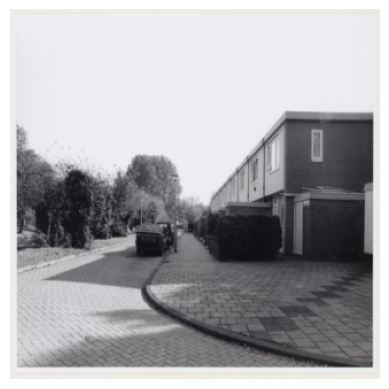

KeyboardInterrupt: 

In [302]:
while 1:
    time.sleep(0.05)
    query_slider.value+=1

In [261]:
query_slider.value=358

In [214]:
for x in correct_per_query_dict["crica"]['amstertime']:
    print(x)

[0]
[1]
[2]
[3]
[4]
[5]
[6]
[7]
[8]
[9]
[10]
[11]
[12]
[13]
[14]
[15]
[16]
[17]
[18]
[19]
[20]
[21]
[22]
[23]
[24]
[25]
[26]
[27]
[28]
[29]
[30]
[31]
[32]
[33]
[34]
[35]
[36]
[37]
[38]
[39]
[40]
[41]
[42]
[43]
[44]
[45]
[46]
[47]
[48]
[49]
[50]
[51]
[52]
[53]
[54]
[55]
[56]
[57]
[58]
[59]
[60]
[61]
[62]
[63]
[64]
[65]
[66]
[67]
[68]
[69]
[70]
[71]
[72]
[73]
[74]
[75]
[76]
[77]
[78]
[79]
[80]
[81]
[82]
[83]
[84]
[85]
[86]
[87]
[88]
[89]
[90]
[91]
[92]
[93]
[94]
[95]
[96]
[97]
[98]
[99]
[100]
[101]
[102]
[103]
[104]
[105]
[106]
[107]
[108]
[109]
[110]
[111]
[112]
[113]
[114]
[115]
[116]
[117]
[118]
[119]
[120]
[121]
[122]
[123]
[124]
[125]
[126]
[127]
[128]
[129]
[130]
[131]
[132]
[133]
[134]
[135]
[136]
[137]
[138]
[139]
[140]
[141]
[142]
[143]
[144]
[145]
[146]
[147]
[148]
[149]
[150]
[151]
[152]
[153]
[154]
[155]
[156]
[157]
[158]
[159]
[160]
[161]
[162]
[163]
[164]
[165]
[166]
[167]
[168]
[169]
[170]
[171]
[172]
[173]
[174]
[175]
[176]
[177]
[178]
[179]
[180]
[181]
[182]
[183]
[184]


In [45]:
query_slider.value+=1